# 34.1 · Sequences and temporal sampling

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain sequences and temporal sampling using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[15 · Video Processing](../../15-video-processing/README.md), [24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [32 · Pose Estimation](../../32-pose-estimation/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Action recognition uses temporal information to classify a sequence. A single frame may show a pose but cannot reliably reveal motion direction or order. The choice of temporal representation determines what evidence a model can use.

## 2. Intuition

A clip samples frames over a time interval. Frame rate, stride and clip length control which motions remain visible. Splits should group related clips by source video or actor to avoid leakage. The synthetic lab uses coordinate trajectories so temporal order is the only useful direction cue.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 34
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
v_t=(x_t-x_{t-1})/\Delta t
$$

xt is position at time t, Δt the time interval and vt the finite-difference velocity. Moving from 4 to 7 pixels in 0.1 seconds gives 30 pixels per second. Frame differences without Δt mix speed with frame rate.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
previous, current, dt = 4.0, 7.0, 0.1
velocity = (current - previous) / dt
assert np.isclose(velocity, 30)
print(velocity)

30.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Generated trajectories become batches of T×2 features; a GRU summarizes them and a head predicts direction. Held-out sequences use an independent random seed.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def actions(lesson, seed, amount):
    configure(seed)
    rng = np.random.default_rng(seed)

    def data(count):
        labels = np.arange(count) % 2
        time = np.linspace(0, 1, 12)
        positions = np.stack(
            [
                np.c_[time if label == 0 else 1 - time, np.ones(12) * rng.uniform(0.2, 0.8)]
                for label in labels
            ]
        )
        positions += rng.normal(0, 0.025 * amount, positions.shape)
        return torch.tensor(positions, dtype=torch.float32), torch.tensor(labels)

    x, y = data(80)
    test, truth = data(20)

    class ActionGRU(nn.Module):
        def __init__(self):
            super().__init__()
            self.gru = nn.GRU(2, 12, batch_first=True)
            self.head = nn.Linear(12, 2)

        def forward(self, x):
            _, h = self.gru(x)
            return self.head(h[-1])

    model = ActionGRU()
    losses = train_supervised(model, x, y, epochs=5, lr=0.01, seed=seed)
    with torch.no_grad():
        pred = model(test).argmax(1)
    return Result(
        "34 · Temporal order and sequence classification",
        curves={"Example x positions over time": x[0, :, 0].numpy(), "Training loss": losses},
        panels={"First two XY sequences": x[:2].reshape(24, 2).numpy()},
        metrics={
            "held_out_direction_accuracy": float((pred == truth).float().mean()),
            "sequence_length": 12,
        },
        notes="The GRU classifies generated motion direction, not intent or human behavior. CNN+RNN, 3D CNN and temporal transformers are discussed in the chapter.",
    )

{
  "held_out_direction_accuracy": 1.0,
  "sequence_length": 12
}
The GRU classifies generated motion direction, not intent or human behavior. CNN+RNN, 3D CNN and temporal transformers are discussed in the chapter.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import TinyCNN

display(Code(inspect.getsource(TinyCNN), language="python"))

class TinyCNN(nn.Module):
    def __init__(self, classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.head = nn.Linear(16 * 3 * 3, classes)

    def forward(self, x):
        return self.head(self.features(x).flatten(1))

## 8. Experiment

Reverse each test sequence and check whether the predicted direction changes. Shuffle frame order and measure the damage.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "held_out_direction_accuracy": 1.0,
    "sequence_length": 12
  },
  "second_seed": {
    "held_out_direction_accuracy": 1.0,
    "sequence_length": 12
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

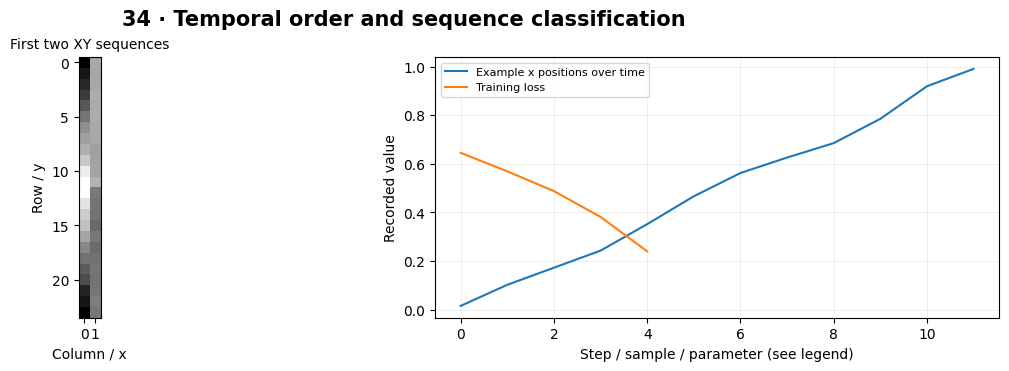

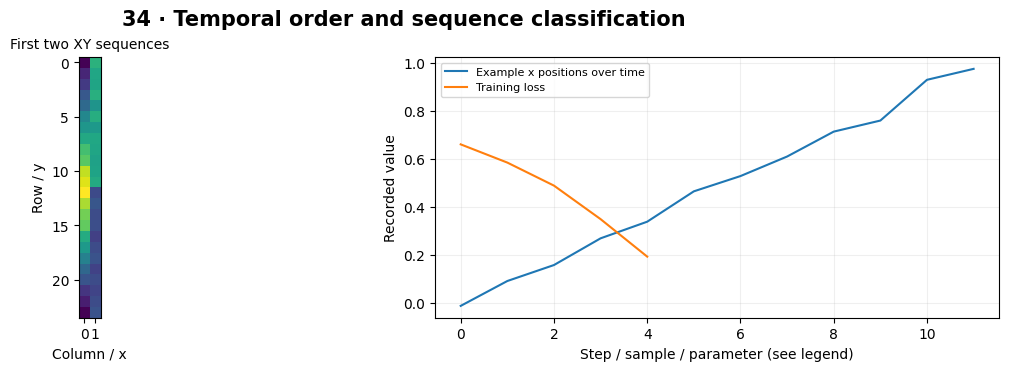

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Action Sequence Classifier**. Classify visible actions without inferring private mental states. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A model may recognize the background or actor instead of the action. Random clip splitting can make evaluation misleadingly easy.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Reverse each test sequence and check whether the predicted direction changes. Shuffle frame order and measure the damage.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a short-clip recognizer with source-grouped splits and separate measurements of recognition delay and compute latency.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A clip samples frames over a time interval. Frame rate, stride and clip length control which motions remain visible. Splits should group related clips by source video or actor to avoid leakage. The synthetic lab uses coordinate trajectories so temporal order is the only useful direction cue.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **CNN–RNN and recurrent state** in this chapter.

[Primary reference](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)